In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/raw/all_schemes_nav.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["scheme_name","date"])

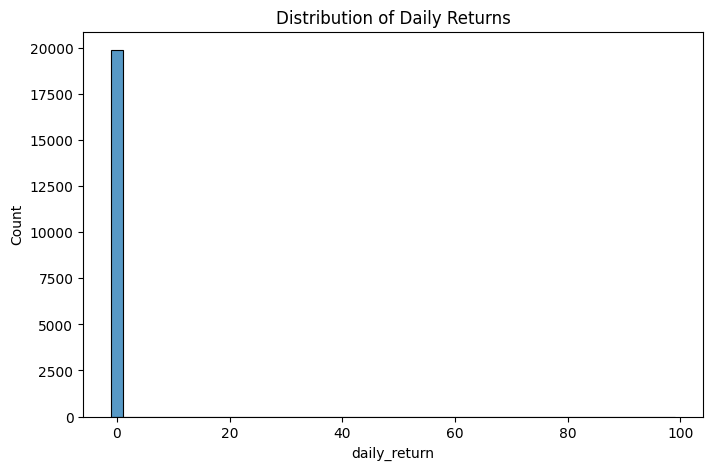

In [6]:
df["daily_return"] = (
    df.groupby("scheme_name")["nav"]
      .pct_change()
)
plt.figure(figsize=(8,5))

sns.histplot(
    df["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.show()

In [9]:
def calculate_cagr(data, years):

    end_date = data["date"].max()

    start_date = end_date - pd.DateOffset(years=years)

    subset = data[data["date"] >= start_date]

    if len(subset) < 2:
        return np.nan

    start_nav = subset.iloc[0]["nav"]

    end_nav = subset.iloc[-1]["nav"]

    return (end_nav/start_nav)**(1/years)-1
results=[]

for scheme in df["scheme_name"].unique():

    temp=df[df["scheme_name"]==scheme]

    results.append({

        "scheme_name":scheme,

        "1Y CAGR":calculate_cagr(temp,1),

        "3Y CAGR":calculate_cagr(temp,3),

        "5Y CAGR":calculate_cagr(temp,5)

    })

cagr=pd.DataFrame(results)

cagr
cagr.to_csv("../reports/cagr.csv",index=False)

In [27]:
rf = 0.065

def sharpe_ratio(returns):
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()

    if len(returns) < 2:
        return np.nan

    std = returns.std()

    if pd.isna(std) or std == 0:
        return np.nan

    excess = returns - (rf / 252)

    return np.sqrt(252) * excess.mean() / std

In [28]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [29]:
sharpe = []

for scheme in df["scheme_name"].unique():

    temp = df[df["scheme_name"] == scheme]

    sharpe.append({
        "scheme_name": scheme,
        "Sharpe": sharpe_ratio(temp["daily_return"])
    })

sharpe = pd.DataFrame(sharpe)
sharpe = sharpe.sort_values("Sharpe", ascending=False)

print(sharpe)

                                         scheme_name    Sharpe
4          SBI Small Cap Fund - Direct Plan - Growth  1.110988
5   quant Mid Cap Fund - Growth Option - Direct Plan  0.695097
3  Nippon India Large Cap Fund - Direct Plan Grow...  0.572915
2  HDFC Money Market Fund - Growth Option - Direc...  0.265457
1  Axis ELSS Tax Saver Fund - Direct Plan - Growt...  0.065877
0  Aditya Birla Sun Life Banking & PSU Debt Fund ... -0.677508


In [11]:
def sortino_ratio(returns):

    downside=returns[returns<0]

    downside_std=downside.std()

    excess=returns-rf/252

    return np.sqrt(252)*excess.mean()/downside_std
sortino=[]

for scheme in df["scheme_name"].unique():

    temp=df[df["scheme_name"]==scheme]

    sortino.append({

        "scheme_name":scheme,

        "Sortino":sortino_ratio(temp["daily_return"].dropna())

    })

sortino=pd.DataFrame(sortino)

sortino

,scheme_name,Sortino
0,Aditya Birla Sun Life Banking & PSU Debt Fund ...,-0.383674
1,Axis ELSS Tax Saver Fund - Direct Plan - Growt...,inf
2,HDFC Money Market Fund - Growth Option - Direc...,648.528278
3,Nippon India Large Cap Fund - Direct Plan Grow...,0.710309
4,SBI Small Cap Fund - Direct Plan - Growth,1.344972
5,quant Mid Cap Fund - Growth Option - Direct Plan,0.808853


In [12]:
def max_drawdown(nav):

    running_max=nav.cummax()

    drawdown=nav/running_max-1

    return drawdown.min()

In [14]:
dd=[]

for scheme in df["scheme_name"].unique():

    temp=df[df["scheme_name"]==scheme]

    dd.append({

        "scheme_name":scheme,

        "Max Drawdown":max_drawdown(temp["nav"])

    })

dd=pd.DataFrame(dd)

dd
dd.to_csv("../reports/max_drawdown.csv",index=False)

In [15]:
score=cagr.merge(sharpe,on="scheme_name")

score=score.merge(dd,on="scheme_name")

In [16]:
score["cagr_rank"]=score["3Y CAGR"].rank(ascending=False)

score["sharpe_rank"]=score["Sharpe"].rank(ascending=False)

score["dd_rank"]=score["Max Drawdown"].rank()

In [17]:
score["Score"]=(
40*score["cagr_rank"]
+
35*score["sharpe_rank"]
+
25*score["dd_rank"]
)

In [18]:
score["Score"]=100*(
score["Score"]-score["Score"].min()
)/(
score["Score"].max()-score["Score"].min()
)


In [19]:
score=score.sort_values("Score",ascending=False)

score
score.to_csv("../reports/fund_scorecard.csv",index=False)

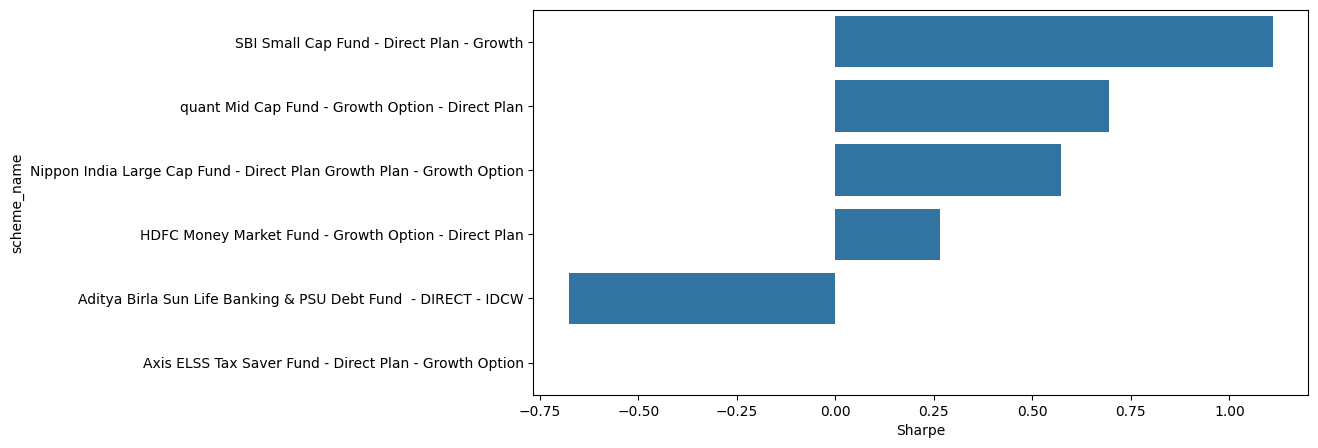

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
data=sharpe,
x="Sharpe",
y="scheme_name"
)

plt.show()

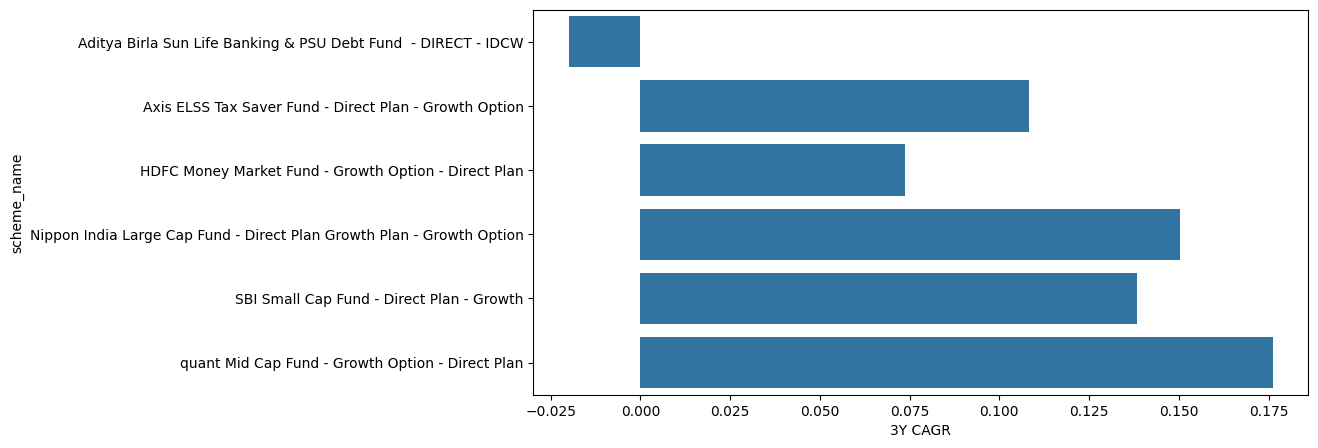

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
data=cagr,
x="3Y CAGR",
y="scheme_name"
)

plt.show()

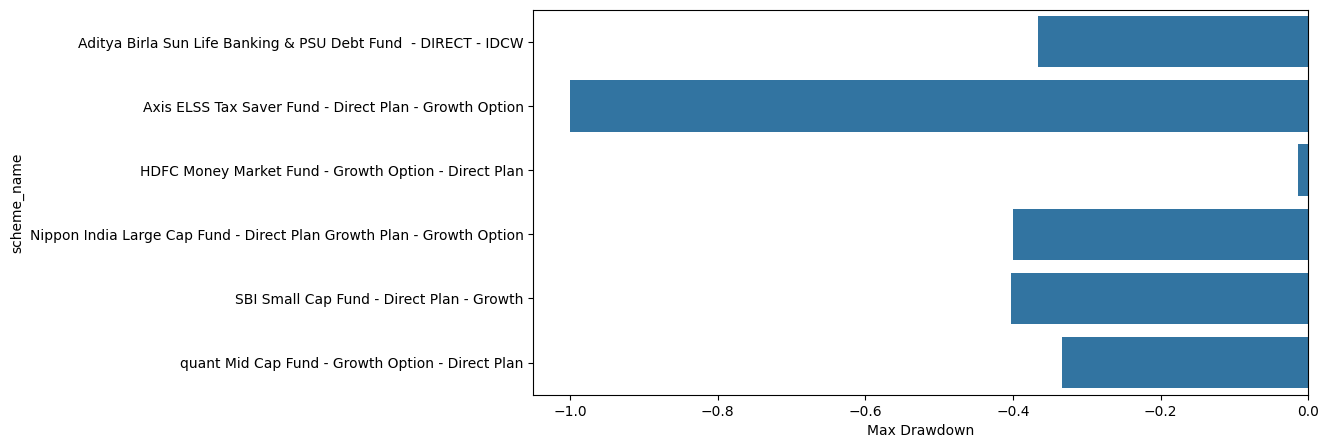

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
data=dd,
x="Max Drawdown",
y="scheme_name"
)

plt.show()